In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [ ]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 

In [3]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    
    # np.log2(num_embeddings) - how many bits for specific codeword    
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

"""
Method for getting patch bits

patch_amount - total detector patch count

encoded_patch_size - encoded_width, encoded_height, num_embeddings

patch_size - patch size
"""

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount * encoded_patch_bits)

def _get_compression_ratio(
        n_hits_total: int, 
        patch_amount: int, 
        encoded_patch_size: tuple, 
        patch_size: int
    ) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    ).as_array()
    return len(event_patches_adcs_flat)
    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [4]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 241.71it/s]


In [5]:
batch_size = 64
beta = 0.31
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 80

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# logs
LOG_EVERY = 15


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [7]:
mse = MeanSquaredError()
mse = mse.to(device)

In [8]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [9]:
event_train = events_train[:SELECTED_EVENTS][0]

In [10]:
patch_amount = _get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [11]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [12]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


In [ ]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

In [ ]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [15]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [16]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        residual_slope: float = 0.08
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x):
        z_encoded = self.encoder(x)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z_encoded)
        
        output = self.decoder(z_q)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [17]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    n_res_layers=2,
    res_h_dim=32
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 282.19it/s, Loss (BCE + VQ)=0.0688]


Epoch [1/80] summary:Average Loss: VQ + BCE = 0.1845,  Average loss: BCE = 0.0747 MSE = 0.009203554506661679 avg_perplexity = 5.005534554845724
Average validation set BCE loss: 0.05469129011034966
Before compression (Training)
Shape: (13, 8, 8)


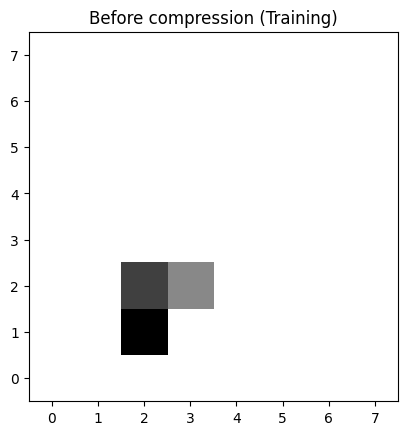

After compression (Training)
Shape: (1, 8, 8)


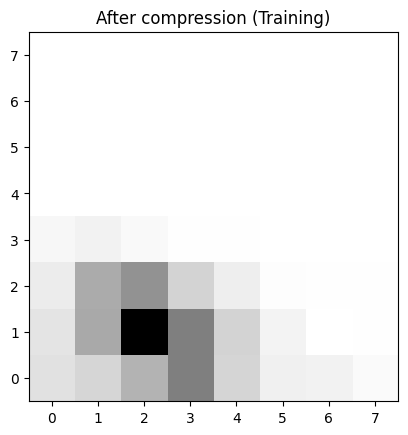

Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 373.77it/s, Loss (BCE + VQ)=0.0476]


Epoch [2/80] summary:Average Loss: VQ + BCE = 0.0564,  Average loss: BCE = 0.0489 MSE = 0.005045401942144013 avg_perplexity = 27.49352314723796
Average validation set BCE loss: 0.044785404950380324


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 357.47it/s, Loss (BCE + VQ)=0.0364]


Epoch [3/80] summary:Average Loss: VQ + BCE = 0.0473,  Average loss: BCE = 0.0425 MSE = 0.003962076772191566 avg_perplexity = 45.115586649832416
Average validation set BCE loss: 0.04044483006000519


Epoch 4/80: 100%|██████████| 199/199 [00:00<00:00, 392.83it/s, Loss (BCE + VQ)=0.0578]


...

Epoch [14/80] summary:Average Loss: VQ + BCE = 0.0360,  Average loss: BCE = 0.0335 MSE = 0.002385623618520459 avg_perplexity = 109.59603693976474
Average validation set BCE loss: 0.03393530659377575


Epoch 15/80: 100%|██████████| 199/199 [00:00<00:00, 395.41it/s, Loss (BCE + VQ)=0.0318]


Epoch [15/80] summary:Average Loss: VQ + BCE = 0.0357,  Average loss: BCE = 0.0333 MSE = 0.002346299812735887 avg_perplexity = 110.1804632637369
Average validation set BCE loss: 0.03441240563988686


Epoch 16/80: 100%|██████████| 199/199 [00:00<00:00, 363.64it/s, Loss (BCE + VQ)=0.0353]


Epoch [16/80] summary:Average Loss: VQ + BCE = 0.0355,  Average loss: BCE = 0.0332 MSE = 0.002309039674451266 avg_perplexity = 112.01322611133058
Average validation set BCE loss: 0.033889006823301315
Before compression (Training)
Shape: (13, 8, 8)


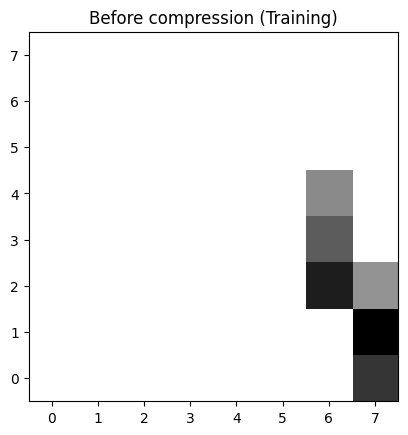

After compression (Training)
Shape: (1, 8, 8)


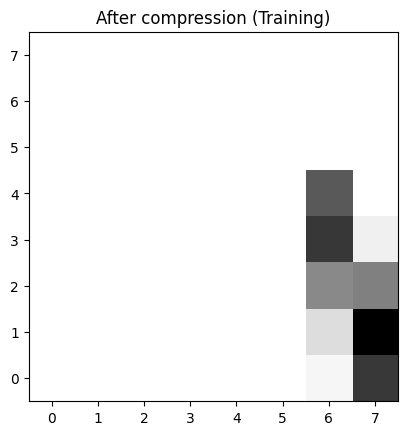

Epoch 17/80: 100%|██████████| 199/199 [00:00<00:00, 373.18it/s, Loss (BCE + VQ)=0.0363]


Epoch [17/80] summary:Average Loss: VQ + BCE = 0.0351,  Average loss: BCE = 0.0328 MSE = 0.002229063608449645 avg_perplexity = 113.18758677957047
Average validation set BCE loss: 0.033980575203895566


Epoch 18/80: 100%|██████████| 199/199 [00:00<00:00, 376.98it/s, Loss (BCE + VQ)=0.0264]


Epoch [18/80] summary:Average Loss: VQ + BCE = 0.0349,  Average loss: BCE = 0.0326 MSE = 0.0021920458164449838 avg_perplexity = 113.88884729356622
Average validation set BCE loss: 0.03392976783215999


Epoch 19/80: 100%|██████████| 199/199 [00:00<00:00, 378.73it/s, Loss (BCE + VQ)=0.0351]


...

Epoch [29/80] summary:Average Loss: VQ + BCE = 0.0332,  Average loss: BCE = 0.0312 MSE = 0.0018730381183120323 avg_perplexity = 116.70958953167326
Average validation set BCE loss: 0.03334073573350906


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 365.29it/s, Loss (BCE + VQ)=0.0237]


Epoch [30/80] summary:Average Loss: VQ + BCE = 0.0331,  Average loss: BCE = 0.0311 MSE = 0.0018455444606390768 avg_perplexity = 115.88057864011832
Average validation set BCE loss: 0.03312486559152603


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 380.01it/s, Loss (BCE + VQ)=0.0363]


Epoch [31/80] summary:Average Loss: VQ + BCE = 0.0329,  Average loss: BCE = 0.0310 MSE = 0.0018131237713404785 avg_perplexity = 115.73829662380506
Average validation set BCE loss: 0.033441397547721866
Before compression (Training)
Shape: (13, 8, 8)


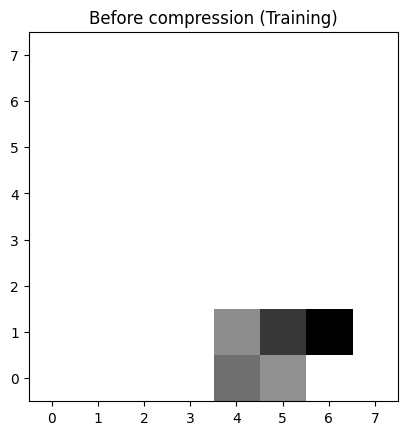

After compression (Training)
Shape: (1, 8, 8)


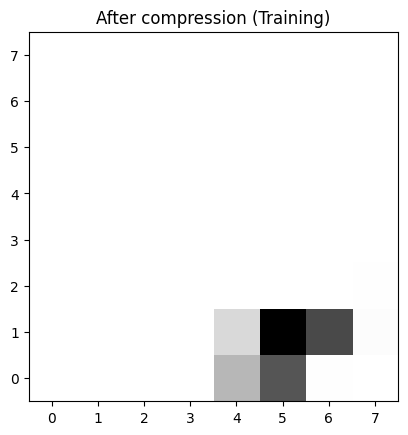

Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 378.84it/s, Loss (BCE + VQ)=0.0317]


Epoch [32/80] summary:Average Loss: VQ + BCE = 0.0329,  Average loss: BCE = 0.0310 MSE = 0.0018151886866488798 avg_perplexity = 115.43369517494087
Average validation set BCE loss: 0.03324596472084522


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 369.53it/s, Loss (BCE + VQ)=0.0403]


Epoch [33/80] summary:Average Loss: VQ + BCE = 0.0328,  Average loss: BCE = 0.0308 MSE = 0.0017586853355169296 avg_perplexity = 115.68348247202198
Average validation set BCE loss: 0.03343679085373878


Epoch 34/80: 100%|██████████| 199/199 [00:00<00:00, 366.98it/s, Loss (BCE + VQ)=0.0238]


...

Epoch [44/80] summary:Average Loss: VQ + BCE = 0.0318,  Average loss: BCE = 0.0300 MSE = 0.0015557269933142105 avg_perplexity = 116.03607135561842
Average validation set BCE loss: 0.03304536007344723


Epoch 45/80: 100%|██████████| 199/199 [00:00<00:00, 378.10it/s, Loss (BCE + VQ)=0.0372]


Epoch [45/80] summary:Average Loss: VQ + BCE = 0.0318,  Average loss: BCE = 0.0300 MSE = 0.0015380515886035434 avg_perplexity = 116.06614986017122
Average validation set BCE loss: 0.03310329951345921


Epoch 46/80: 100%|██████████| 199/199 [00:00<00:00, 351.83it/s, Loss (BCE + VQ)=0.0242]


Epoch [46/80] summary:Average Loss: VQ + BCE = 0.0317,  Average loss: BCE = 0.0299 MSE = 0.001519671439172129 avg_perplexity = 116.396390138559
Average validation set BCE loss: 0.033166204765439036
Before compression (Training)
Shape: (13, 8, 8)


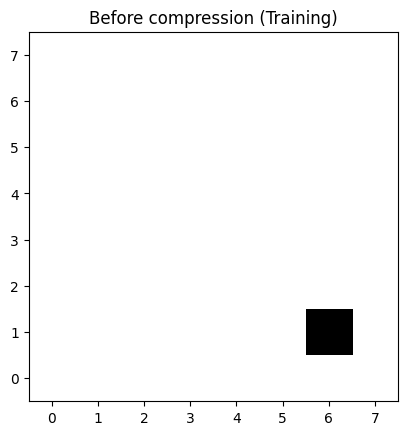

After compression (Training)
Shape: (1, 8, 8)


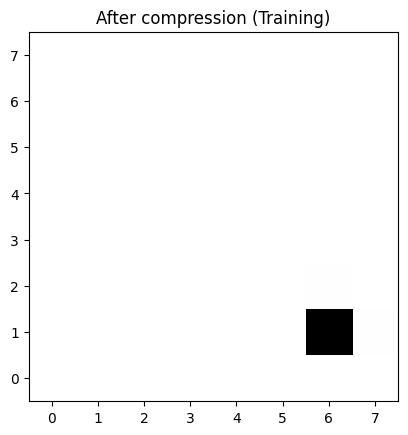

Epoch 47/80: 100%|██████████| 199/199 [00:00<00:00, 357.01it/s, Loss (BCE + VQ)=0.0219]


Epoch [47/80] summary:Average Loss: VQ + BCE = 0.0316,  Average loss: BCE = 0.0298 MSE = 0.001497842925752808 avg_perplexity = 116.3031620619884
Average validation set BCE loss: 0.033496011048555374


Epoch 48/80: 100%|██████████| 199/199 [00:00<00:00, 358.65it/s, Loss (BCE + VQ)=0.0321]


Epoch [48/80] summary:Average Loss: VQ + BCE = 0.0316,  Average loss: BCE = 0.0298 MSE = 0.0014885018319921127 avg_perplexity = 116.20005577892515
Average validation set BCE loss: 0.03331776633858681


Epoch 49/80: 100%|██████████| 199/199 [00:00<00:00, 365.28it/s, Loss (BCE + VQ)=0.0336]


...

Epoch [59/80] summary:Average Loss: VQ + BCE = 0.0310,  Average loss: BCE = 0.0293 MSE = 0.0013379267283514067 avg_perplexity = 116.20569179285711
Average validation set BCE loss: 0.033088835328817366


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 353.08it/s, Loss (BCE + VQ)=0.0273]


Epoch [60/80] summary:Average Loss: VQ + BCE = 0.0308,  Average loss: BCE = 0.0292 MSE = 0.0012973552363826403 avg_perplexity = 115.56409920160495
Average validation set BCE loss: 0.03305552825331688


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 354.55it/s, Loss (BCE + VQ)=0.0364]


Epoch [61/80] summary:Average Loss: VQ + BCE = 0.0308,  Average loss: BCE = 0.0292 MSE = 0.001295478404651691 avg_perplexity = 115.66730073708386
Average validation set BCE loss: 0.033307723328471185
Before compression (Training)
Shape: (13, 8, 8)


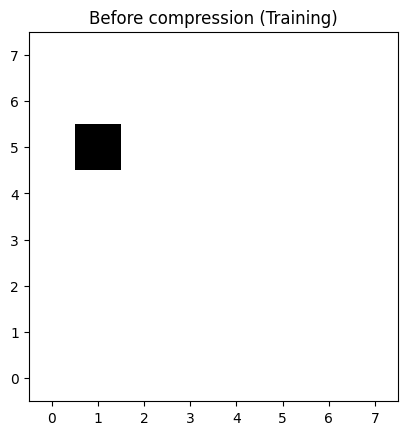

After compression (Training)
Shape: (1, 8, 8)


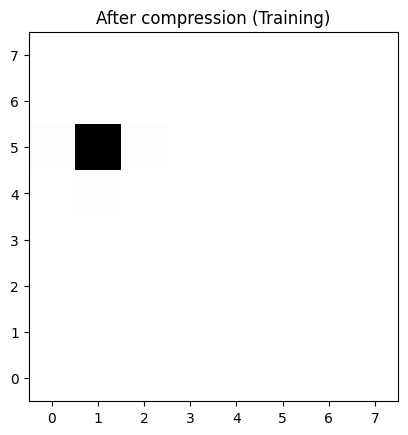

Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 369.73it/s, Loss (BCE + VQ)=0.0258]


Epoch [62/80] summary:Average Loss: VQ + BCE = 0.0307,  Average loss: BCE = 0.0291 MSE = 0.0012788705342921928 avg_perplexity = 115.04416880775337
Average validation set BCE loss: 0.03317980021238327


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 368.89it/s, Loss (BCE + VQ)=0.0318]


Epoch [63/80] summary:Average Loss: VQ + BCE = 0.0307,  Average loss: BCE = 0.0291 MSE = 0.0012551448474656885 avg_perplexity = 114.6689027182421
Average validation set BCE loss: 0.03271736204624176


Epoch 64/80: 100%|██████████| 199/199 [00:00<00:00, 353.42it/s, Loss (BCE + VQ)=0.0275]


...

Epoch [74/80] summary:Average Loss: VQ + BCE = 0.0303,  Average loss: BCE = 0.0288 MSE = 0.0011537933067521594 avg_perplexity = 115.15135835043749
Average validation set BCE loss: 0.03298086598515511


Epoch 75/80: 100%|██████████| 199/199 [00:00<00:00, 373.42it/s, Loss (BCE + VQ)=0.0339]


Epoch [75/80] summary:Average Loss: VQ + BCE = 0.0302,  Average loss: BCE = 0.0286 MSE = 0.0011071569482847374 avg_perplexity = 115.51981777402025
Average validation set BCE loss: 0.032733253017067906


Epoch 76/80: 100%|██████████| 199/199 [00:00<00:00, 366.97it/s, Loss (BCE + VQ)=0.0232]


Epoch [76/80] summary:Average Loss: VQ + BCE = 0.0301,  Average loss: BCE = 0.0286 MSE = 0.0011030843695824563 avg_perplexity = 115.09782570690366
Average validation set BCE loss: 0.032975444197654726
Before compression (Training)
Shape: (13, 8, 8)


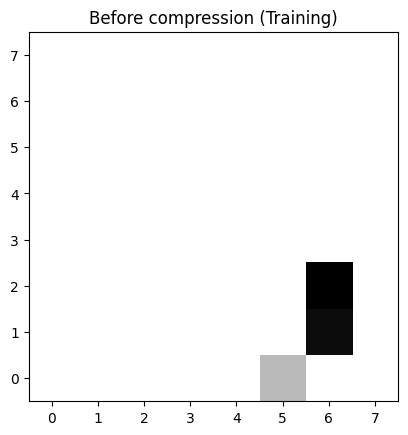

After compression (Training)
Shape: (1, 8, 8)


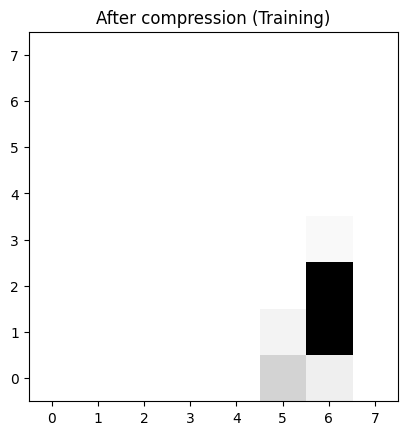

Epoch 77/80: 100%|██████████| 199/199 [00:00<00:00, 365.23it/s, Loss (BCE + VQ)=0.0369]


Epoch [77/80] summary:Average Loss: VQ + BCE = 0.0300,  Average loss: BCE = 0.0285 MSE = 0.001078769109204842 avg_perplexity = 114.72151047979767
Average validation set BCE loss: 0.033183814585208894


Epoch 78/80: 100%|██████████| 199/199 [00:00<00:00, 355.76it/s, Loss (BCE + VQ)=0.028] 


Epoch [78/80] summary:Average Loss: VQ + BCE = 0.0300,  Average loss: BCE = 0.0285 MSE = 0.0010877489963494916 avg_perplexity = 114.4482723983688
Average validation set BCE loss: 0.03302112594246864


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 356.25it/s, Loss (BCE + VQ)=0.0239]


Epoch [79/80] summary:Average Loss: VQ + BCE = 0.0299,  Average loss: BCE = 0.0284 MSE = 0.001059670627512618 avg_perplexity = 114.43425777569487
Average validation set BCE loss: 0.03285532593727112


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 368.33it/s, Loss (BCE + VQ)=0.0289]


Epoch [80/80] summary:Average Loss: VQ + BCE = 0.0299,  Average loss: BCE = 0.0285 MSE = 0.0010666253557662718 avg_perplexity = 114.86272114125927
Average validation set BCE loss: 0.03286202922463417
Before compression (Validation)
Shape: (64, 8, 8)


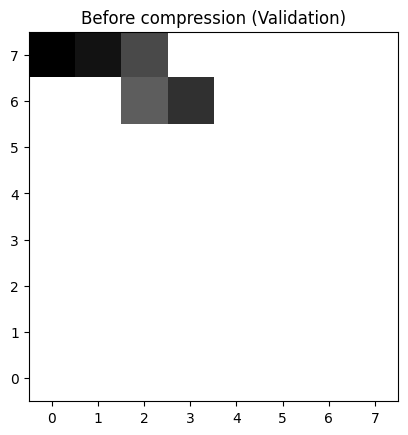

After compression (Validation)
Shape: (1, 8, 8)


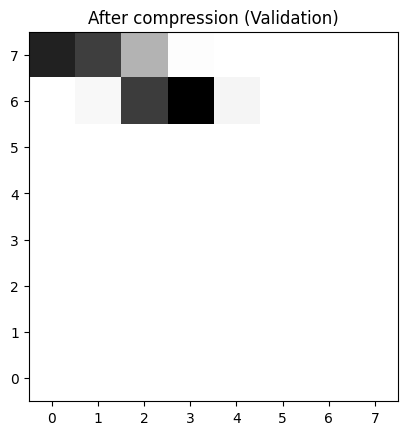

----------------------------------------
Patch = 0 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


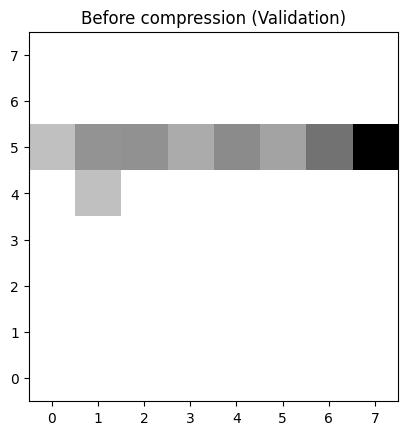

After compression (Validation)
Shape: (1, 8, 8)


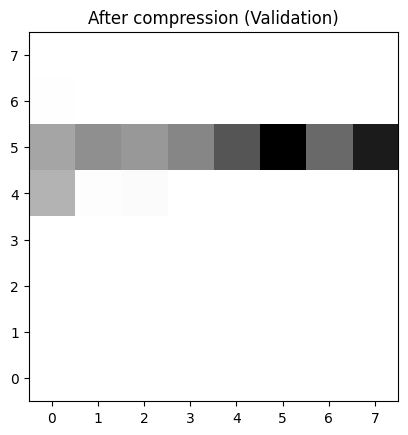

----------------------------------------
Patch = 1 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


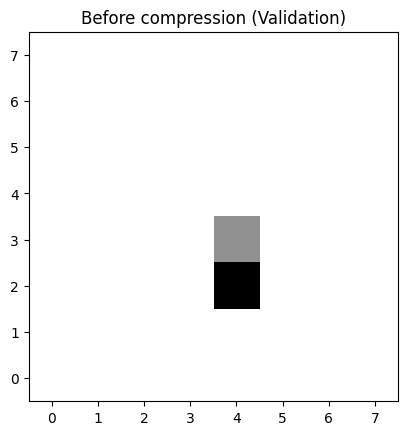

After compression (Validation)
Shape: (1, 8, 8)


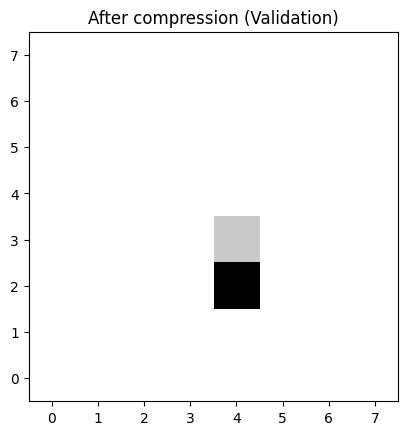

----------------------------------------
Patch = 2 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


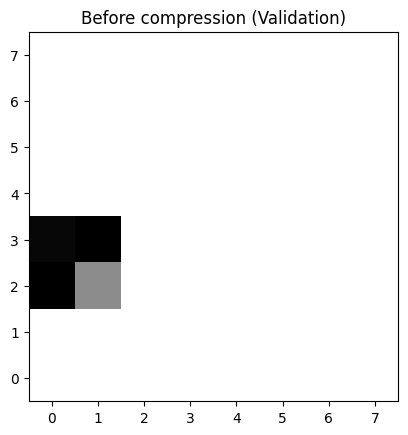

After compression (Validation)
Shape: (1, 8, 8)


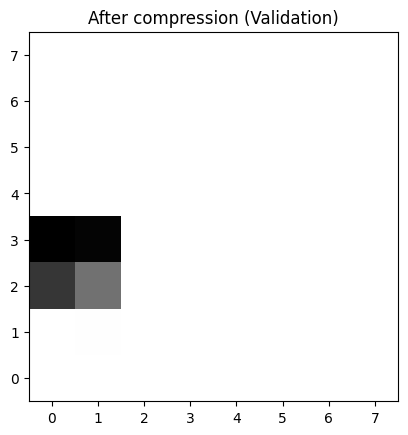

----------------------------------------
Patch = 3 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (61, 8, 8)


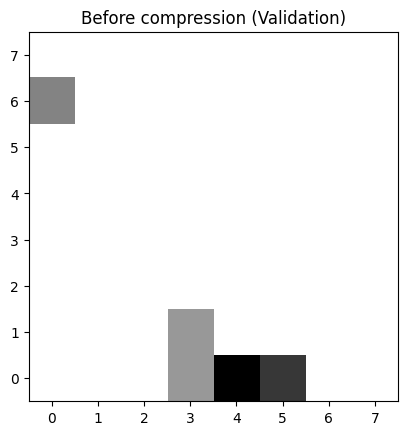

After compression (Validation)
Shape: (1, 8, 8)


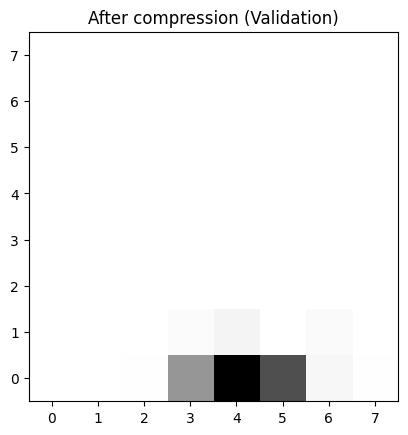

----------------------------------------
Patch = 4 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Saving trained model VQ-VAE


In [18]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = _tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = _tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(_tensor_to_numpy(codebook_train))
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = _tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = _tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                plot_patch(recon_patch_np_val[0], "After compression (Validation)")
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = _tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                width_val, height_val = z_q_val[0][0].shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
                compression_ratio = _get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(width_val, height_val, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = _get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = _get_encoded_patch_bits(
                    (width_val, height_val, num_embeddings), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "vqvae.pth")

In [19]:
# logvar_values = logvar.detach().cpu().flatten().numpy()
# # histogram
# plt.hist(logvar_values, bins=50)

# plt.title("VAE Latent logvar Distribution")
# plt.xlabel("logvar")
# plt.ylabel("count")

# plt.show()

In [20]:
# TODO
# Compression ratio calculation
# Find total sum of hit bits
# Find total sum of encoded patch bits
total_bits = _get_total_hit_bits(total_hit_amount)


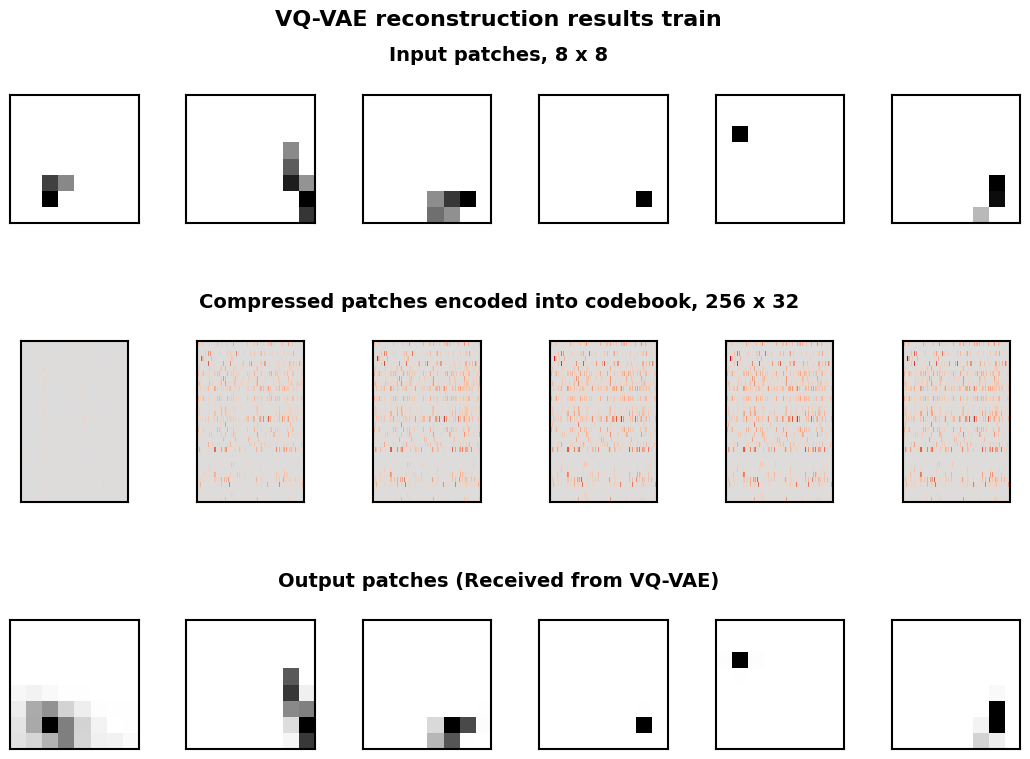

In [21]:
def plot_patches(patch_rows: list[tuple], title: str) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    fig = plt.figure(figsize=(2.2 * cols, 8.5))

    gs = GridSpec(
        rows,
        cols,
        figure=fig,
        height_ratios=[1.2, 1.5, 1.2],
        wspace=0.25,
        hspace=0.85
    )

    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
        y=0.98
    )
    
    global_abs_max = max(
        p.detach().cpu().abs().max().item()
        if hasattr(p, "detach") else abs(p).max()
        for p in patch_rows[1][0]
    )

    for i in range(rows):
        patch_row, patch_row_title = patch_rows[i]

        # Row title aligned above each row
        row_top = gs[i, :].get_position(fig).y1
        fig.text(
            0.5,
            row_top + 0.035,
            patch_row_title,
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold"
        )

        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])

            patch = patch_row[j]

            # Keep your current row-1 transpose logic
            if i == 1:
                patch = patch.T

                im = ax.imshow(
                    patch,
                    cmap="coolwarm",
                    origin="lower",
                    aspect="auto",
                    interpolation="nearest",
                    vmin=-global_abs_max,
                    vmax=global_abs_max
                )

                ax.set_box_aspect(1.5)


            else:
                im = ax.imshow(
                    patch,
                    cmap="gist_yarg",
                    origin="lower",
                    aspect="equal"
                )

                # Square input/output patches
                ax.set_box_aspect(1.0)

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

    plt.show()
        
        
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results train")

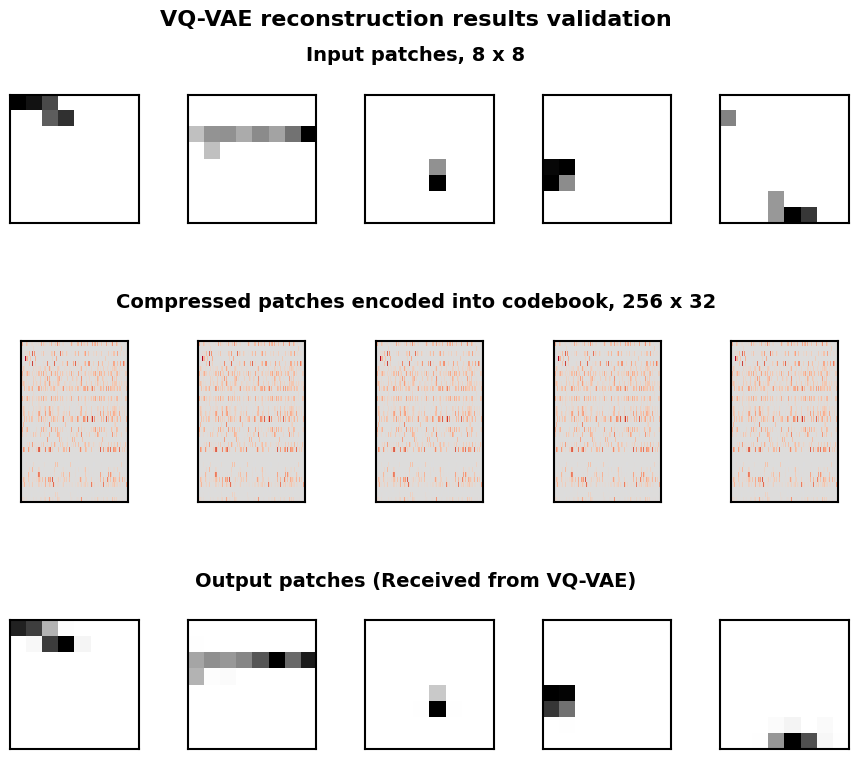

In [22]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results validation")

In [23]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.03948819637298584
encoder.1.weight 0.003955284133553505
encoder.1.bias 0.004257011692970991
encoder.3.weight 0.0695134848356247
encoder.4.weight 0.0031931481789797544
encoder.4.bias 0.003111314494162798
encoder.6.weight 0.08932502567768097
encoder.7.weight 0.013510524295270443
encoder.7.bias 0.014613168314099312
encoder.8.stack.0.res_block.1.weight 0.02603774145245552
encoder.8.stack.0.res_block.3.weight 0.035174138844013214
encoder.8.stack.1.res_block.1.weight 0.028636587783694267
encoder.8.stack.1.res_block.3.weight 0.014199614524841309
vq_layer.embedding.weight 0.00044743382022716105
decoder.0.weight 0.03057393617928028
decoder.1.weight 0.003935118205845356
decoder.1.bias 0.0029819842893630266
decoder.2.stack.0.res_block.1.weight 0.00859050266444683
decoder.2.stack.0.res_block.3.weight 0.008521545678377151
decoder.2.stack.1.res_block.1.weight 0.010204382240772247
decoder.2.stack.1.res_block.3.weight 0.0065815686248242855
decoder.3.weight 0.

VQ VAE, BCE encoder average loss values over epochs


/tmp/ipykernel_473836/831797292.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


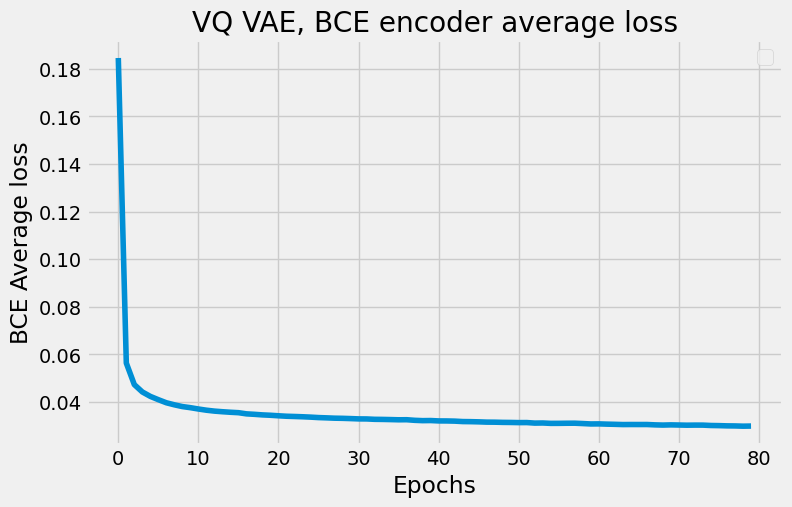

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [24]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [25]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(_tensor_to_numpy(codebook_test))
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 45), average BCE loss = 0.24101
Based on test set (size = 45), average codebook perplexity = 115.09170/256
Saved VQ-VAE test results


In [26]:
len(patches_before_test)

6

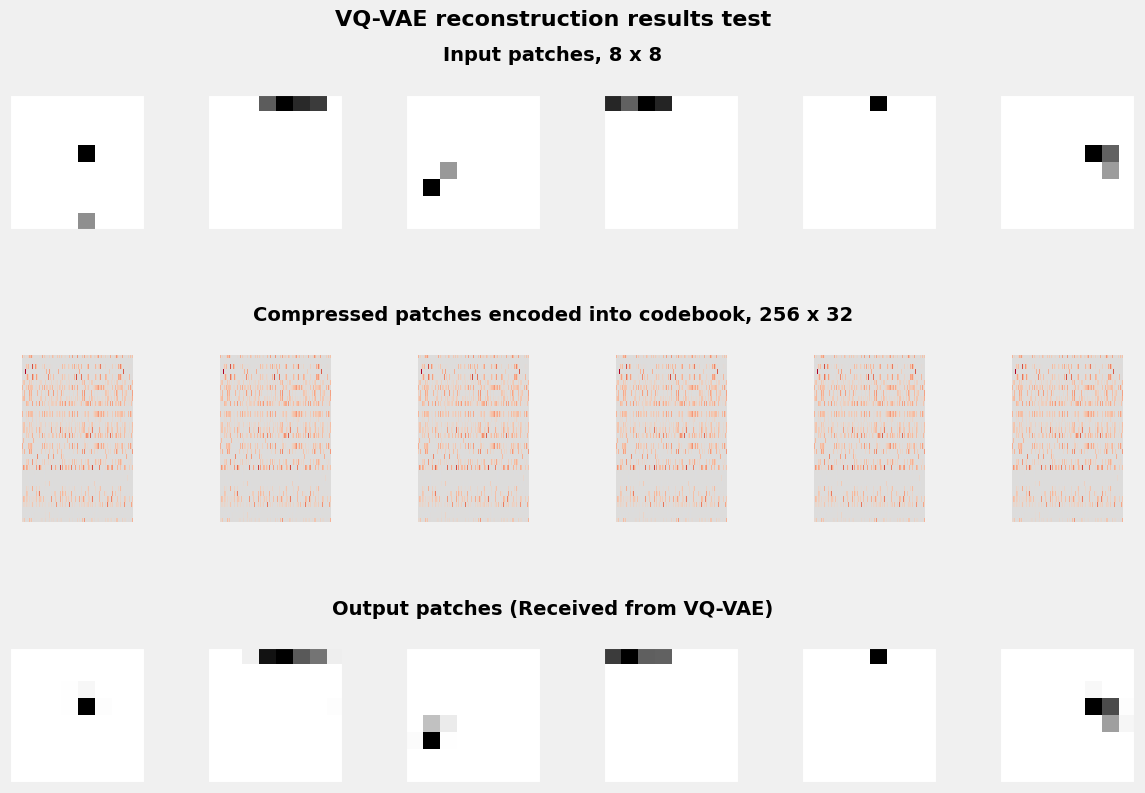

In [27]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results test")

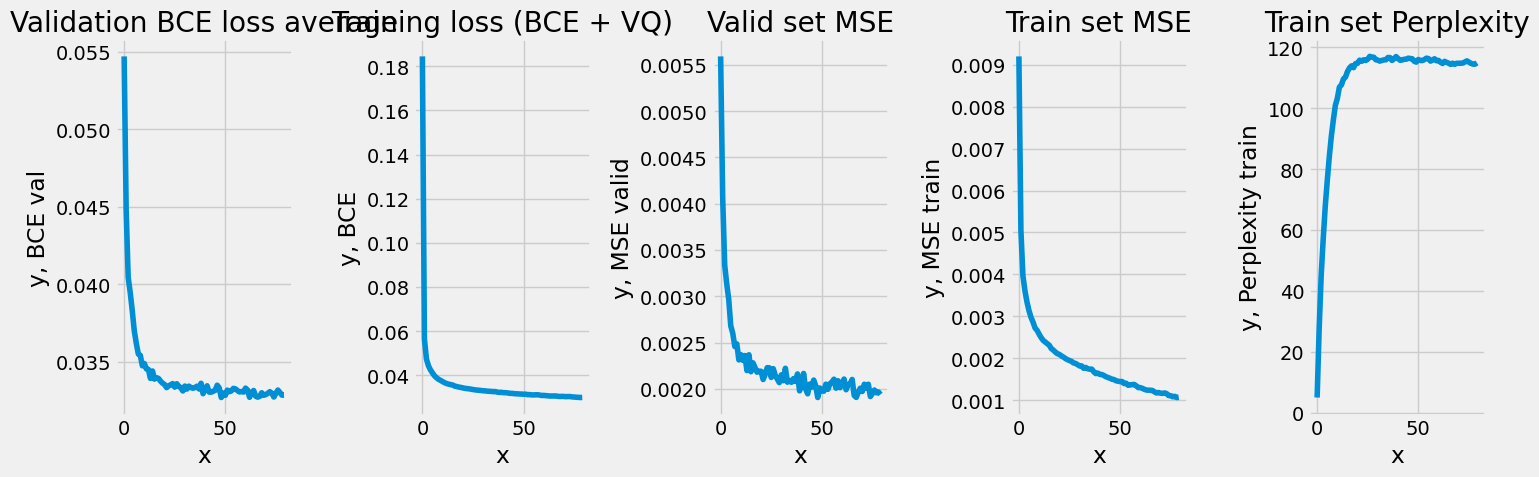

In [28]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 5))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

Results:
<!-- * Perplexity shows that per patch about 10 from 16 codebook entries are used
* Reconstruction quality is about average. Representations with validation and test tests
look marginally similar to the input images
* Compression ratio shows that input image successfully was scaled about 3 times (~2.8).
* 1 encoded patch has 27 bits, while 1 encoded patch in VAE has 128 bits. 
* beta = 4e-3 (commitment cost) given better results. Beta needs to be very small and once smaller, gives better results. Based on official VQ-VAE research paper, image compression, requires beta to in the inverval [0.1, 2.0] -->
* Codebook entries from 16 vectors (rows), only approximately 8 codebook entries are used based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction
* Validation set properly works with higher beta coeficient
* Codebook plots describe codebook variation, whether certain weights are mostly zero and are codebook usage is not sparse